In [2]:
import logging
import os
import sys
import traceback
from tqdm import tqdm 

from hydra import initialize, compose
import numpy as np
import pandas as pd
from omegaconf import DictConfig
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import torch

import sys 
sys.path.insert(0, "../../../../../shared_utils")
from experiment_utils import get_forward_model

from torch.utils.data import TensorDataset, DataLoader

Collect the configurations 

In [3]:
with initialize(config_path="../../../../../inverse/loss_guidance/config", version_base=None):
    config = compose(config_name="run_inverse",
                    overrides=[
                        "paths=default"  
                    ])

Load forward model and classifier 

In [4]:
logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)

# Read data

In [14]:
train_data_phi = flow_matching.train_data.state_data
valid_data_phi = flow_matching.validation_data[0].state_data

In [15]:
annot_train = np.array(flow_matching.train_data.adata.obs.index)
annot_valid = np.array(flow_matching.validation_data[0].adata.obs.index)

In [17]:
train_data_phi.shape

(92953367, 27)

In [18]:
valid_data_phi.shape

(322087, 27)

In [22]:
train_data_phi.shape[0] + valid_data_phi.shape[0]

93275454

In [23]:
X_concat = torch.from_numpy(np.concatenate([train_data_phi, valid_data_phi], axis=0))
annot_concat = np.concatenate([annot_train, annot_valid])

## Tensor dataset for data 

In [24]:
# Classifier model 
target_prediction = forward_model.target_prediction_model
target_prediction.eval()

RescaledTargetPredictionModel(
  (resc_model): ModuleDict(
    (inv_params): IZNorm(
      (params): ModuleDict(
        (mean): ModelParam()
        (covariance): ModelParam()
      )
    )
    (fwd_params): ZNorm(
      (params): ModuleDict(
        (mean): ModelParam()
        (covariance): ModelParam()
      )
    )
    (model): PerturbationApproximatePosterior(
      (pert_approximate_posterior): ModuleDict(
        (encoder): MLPBlock(
          (net): Sequential(
            (0): Sequential(
              (0): Linear(in_features=27, out_features=2048, bias=True)
              (1): ReLU()
              (2): Dropout(p=0.75, inplace=False)
            )
            (1): Sequential(
              (0): Linear(in_features=2048, out_features=2048, bias=True)
              (1): ReLU()
              (2): Dropout(p=0.75, inplace=False)
            )
            (2): Sequential(
              (0): Linear(in_features=2048, out_features=2048, bias=True)
              (1): ReLU()
            

In [25]:
dataloader = DataLoader(
    torch.utils.data.TensorDataset(X_concat), 
    batch_size=4026,
    shuffle=False
)

In [26]:
ct_predictions = []

with torch.no_grad():
    for batch in tqdm(dataloader):
        X_batch = batch[0].to(target_prediction_model.device)
        y_pred = target_prediction(X_batch)["cell_type"].argmax(1)
        ct_predictions.append(y_pred.cpu().detach().numpy())

100%|██████████| 23169/23169 [09:11<00:00, 42.04it/s]


In [27]:
# Save predictions 
ct_predictions = np.concatenate(ct_predictions)

In [28]:
from sklearn.preprocessing import LabelEncoder

# Prepare label encoder
ct_le = LabelEncoder()
ct_values = target_prediction_model.train_data.adata.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())

In [29]:
# Assign string to all cells 
ct_predictions_str = classes[ct_predictions]

In [30]:
ct_predictions_str

array(['GMP-Cycle', 'pDCs/cDCs', 'MPP', ..., 'EosBasoMastPre_2',
       'EosBasoMastPre', 'MEP'], shape=(93275454,), dtype='<U20')

In [33]:
pd.DataFrame(ct_predictions_str).value_counts().sum()

np.int64(93275454)

In [32]:
del train_data_phi
del valid_data_phi
del X_concat

Read and annotate real data 

In [34]:
adata_real = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/dataset_unmix8/HID01_fcs_concatenated_logicle.h5ad")

In [35]:
adata_real.obs.loc[annot_concat, "cell_type"] = ct_predictions_str

Plot and color a subset 

In [116]:
adata_real_subset = sc.pp.subsample(adata_real, n_obs=100_000,  random_state=42, copy=True)

In [117]:
sc.tl.pca(adata_real_subset)
sc.pp.neighbors(adata_real_subset)
sc.tl.umap(adata_real_subset)

CD14-Mono


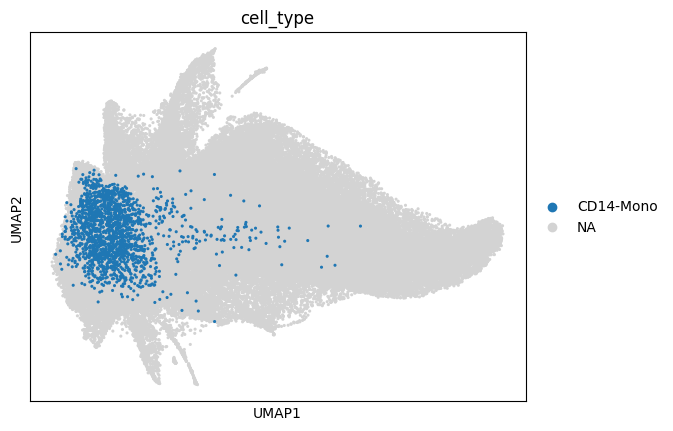

CD49c-Myeloid


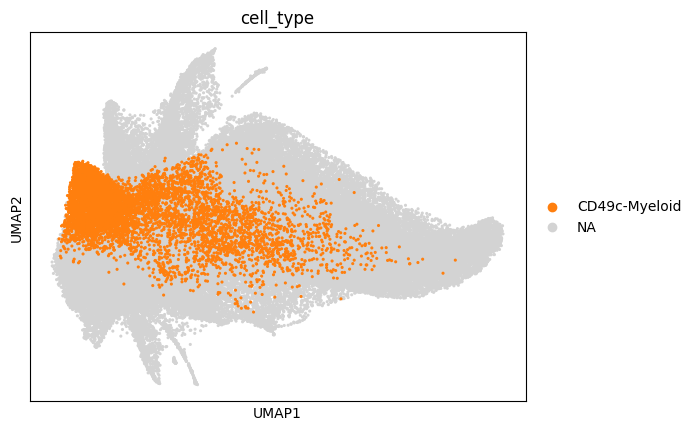

CyclingProgenitor*


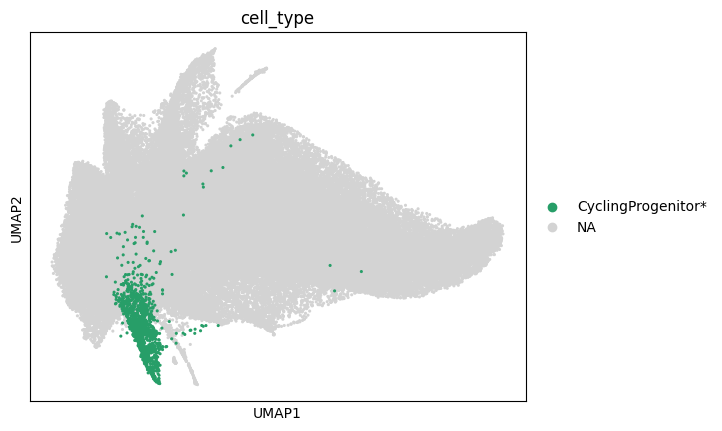

DCs-CD14


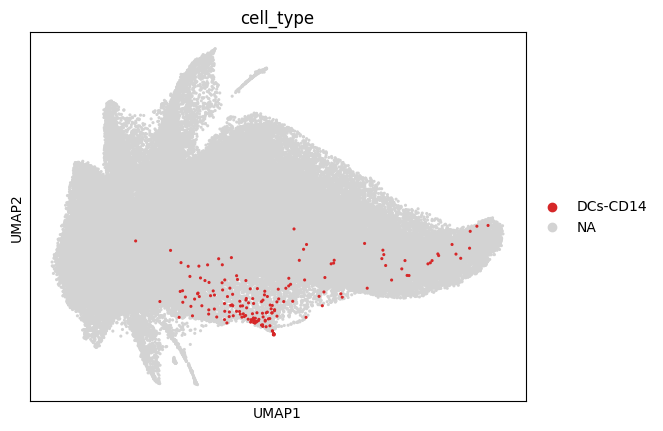

EarlyGMP


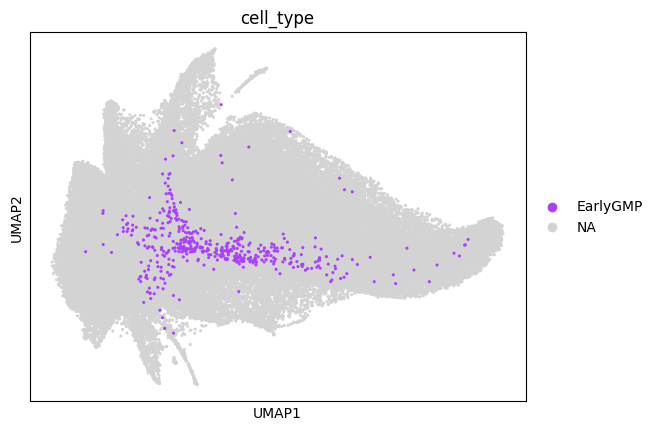

Early_Pro-B


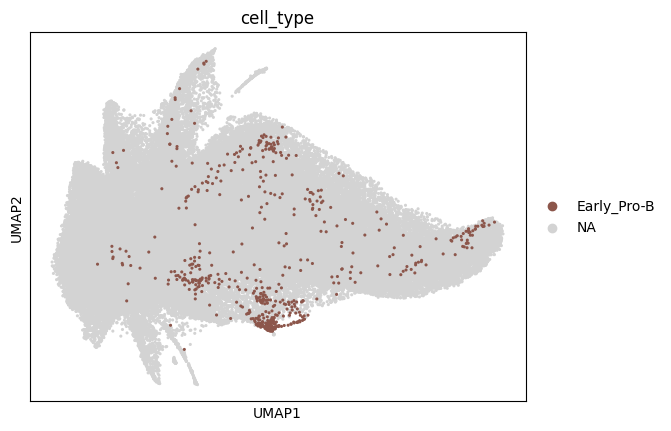

EosBasoMastPre


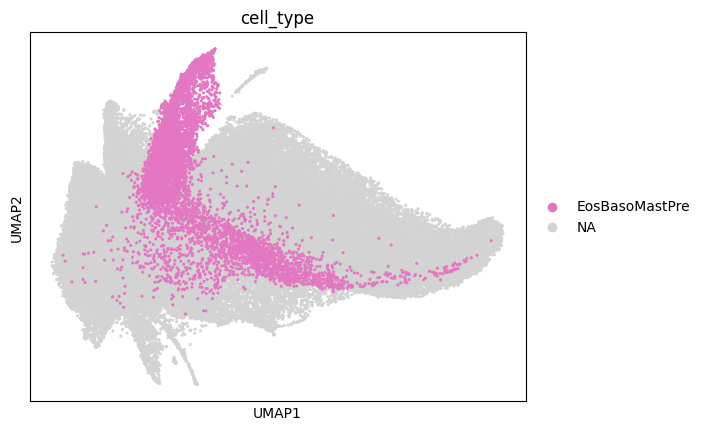

EosBasoMastPre_2


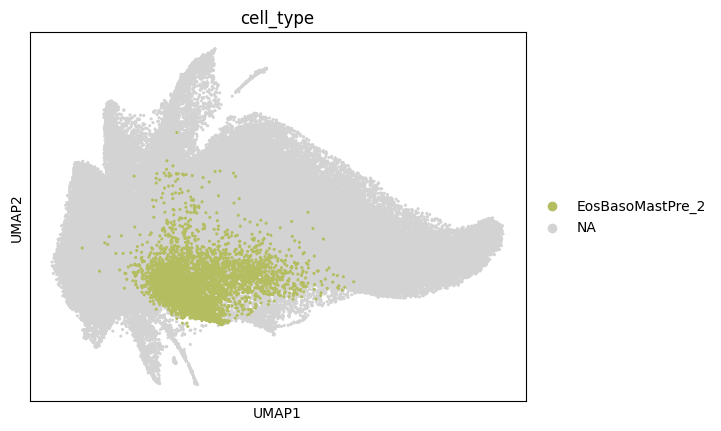

EryPro


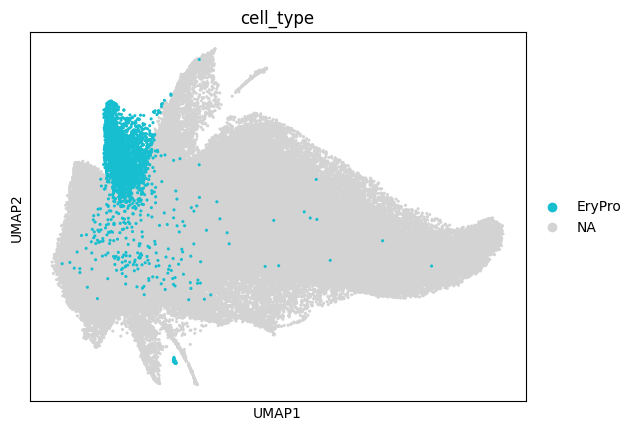

GMP-Cycle


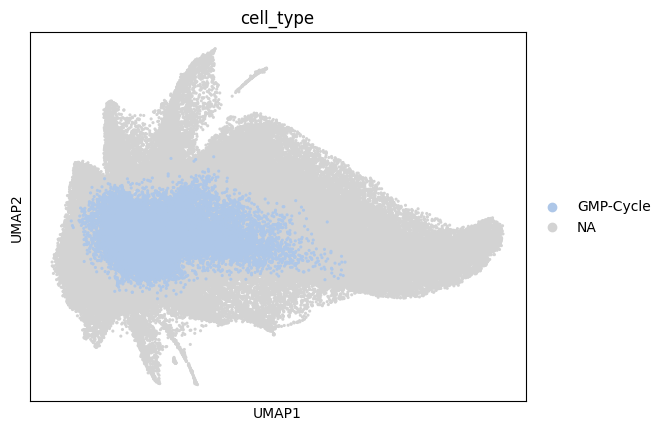

GMP-Neutro


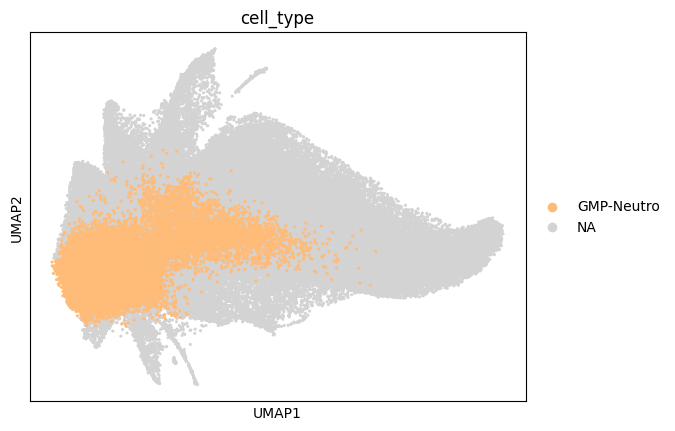

GMP-Neutro/CD16-Mono


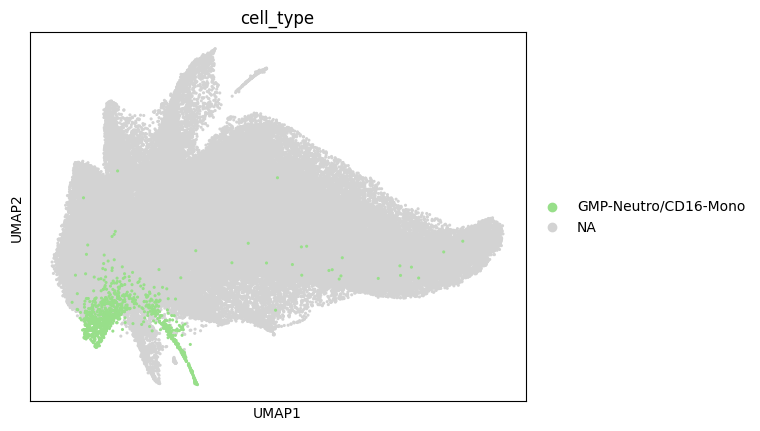

HSCs


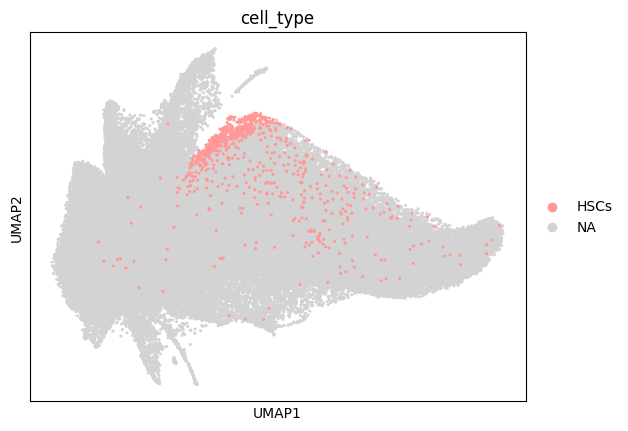

MEP


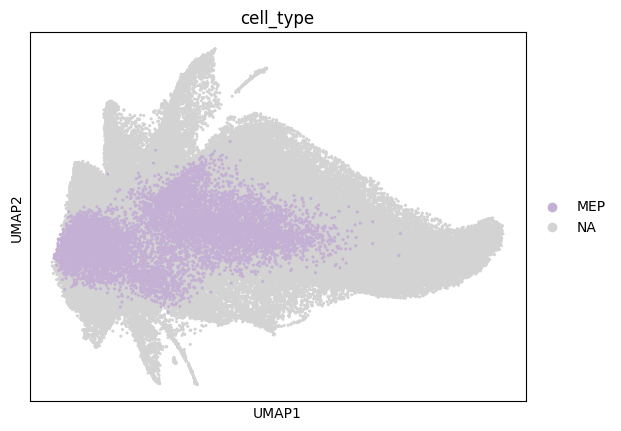

MLP


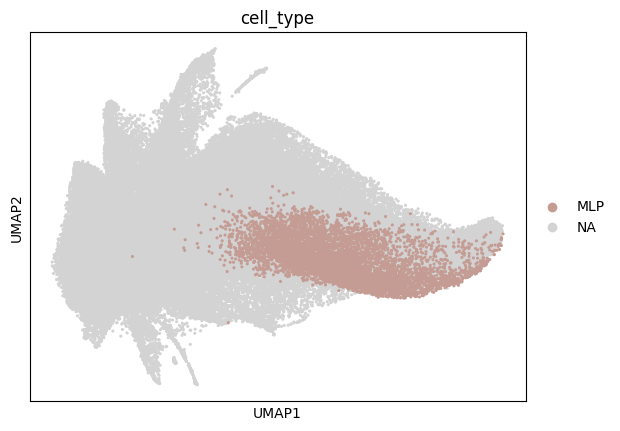

MPP


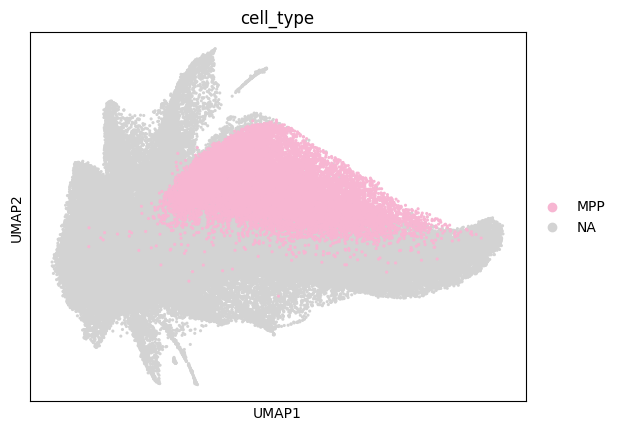

MgkPro


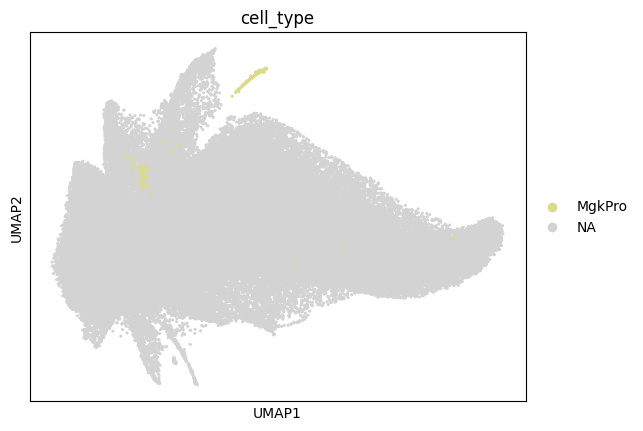

Pro-B


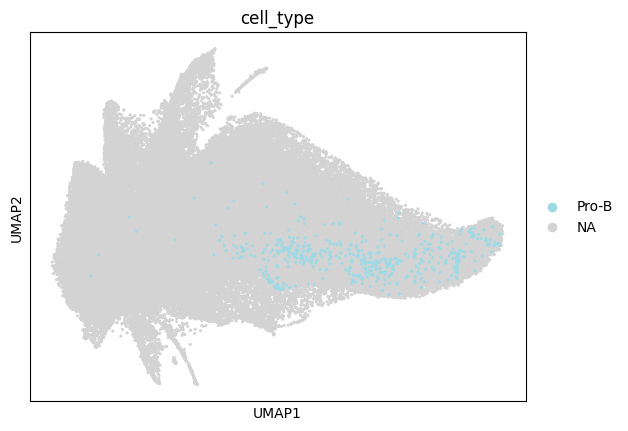

pDCs/cDCs


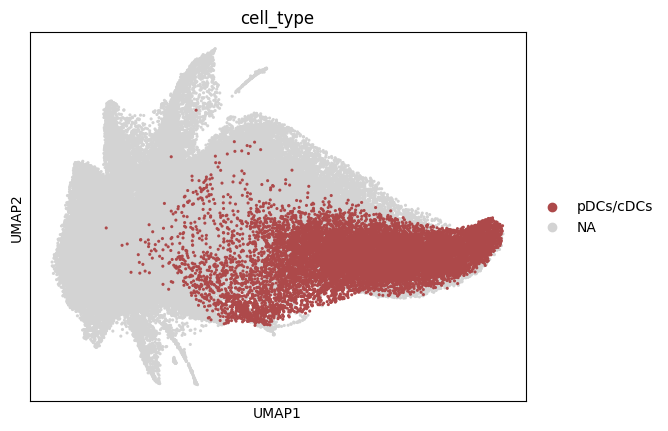

In [128]:
for cell_type in np.unique(adata_real_subset.obs.cell_type): 
    print(cell_type)
    sc.pl.umap(adata_real_subset,
               color="cell_type",
               groups=cell_type,
               # legend_loc="on data",
               s=20)

In [119]:
# del adata_real_subset

In [110]:
pd.DataFrame(ct_predictions_str).value_counts() / ct_predictions_str.shape[0]

0                   
MPP                     0.171783
GMP-Neutro              0.145830
GMP-Cycle               0.134347
pDCs/cDCs               0.133676
MEP                     0.082247
CD49c-Myeloid           0.067696
EosBasoMastPre          0.064717
MLP                     0.057694
EosBasoMastPre_2        0.043446
EryPro                  0.031415
CD14-Mono               0.017853
CyclingProgenitor*      0.012769
GMP-Neutro/CD16-Mono    0.009347
HSCs                    0.007561
Early_Pro-B             0.006028
Pro-B                   0.004811
EarlyGMP                0.004739
MgkPro                  0.002206
DCs-CD14                0.001833
Name: count, dtype: float64

# Perform protocol analysis

In [48]:
cell_types = ["CD14-Mono",
              "CyclingProgenitor*",
              "DCs-CD14",
              "Early_Pro-B", 
              "EosBasoMastPre", 
              "EryPro",
              "GMP-Neutro:CD16-Mono",
              "HSCs",
              "MgkPro",
              "Pro-B"]

In [49]:
protocol_columns = ["740-yp_[µm]", 
                   "mtg_[µm]", 
                   "rhflt3l_[ng_ml]", 
                   "gm-csf_[ng_ml]", 
                   "tpo_[ng_ml]",
                   "sr1_[nm]", 
                   "um171_[nm]", 
                   "um729_[µm]", 
                   "scf_[ng_ml]",
                   "butyzamide_[nm]",
                   "retinoic_acid_[µm]",
                   "ldl_[ng_ml]", 
                   "il3_[ng_ml]", 
                   "o2_[%]", 
                   "days_of_culture"]

We will create an AnnData with unique protocols as `.obs` dimensions

In [50]:
# Unique protocols 
obs_protocols = adata_real.obs.loc[:, protocol_columns].values.astype(float)

In [87]:
seen = {}
unique = []

for prot in tqdm(obs_protocols):
    key = prot.tobytes()
    if key not in seen:
        seen[key] = prot
        unique.append(prot)

iseen = {"_".join(list(val.astype(str))):key for key, val in seen.items()}

100%|██████████| 93275454/93275454 [00:47<00:00, 1955726.83it/s]


In [88]:
X_protocols = np.stack(unique, axis=0)

In [89]:
X_protocols.shape

(117, 15)

There are 117 unique protocols 

Create hashes 

In [90]:
# Save real protocol ids 
real_data_prot_id = []
for i in tqdm(range(obs_protocols.shape[0])):
    protocol_i_str_to_byte = obs_protocols[i].tobytes()
    if protocol_i_str_to_byte in seen:
        real_data_prot_id.append(protocol_i_str_to_byte)
    else:
        raise ValueError

100%|██████████| 93275454/93275454 [01:04<00:00, 1444575.37it/s]


In [91]:
real_data_prot_id = np.array(real_data_prot_id)

In [93]:
adata_real.obs["protocol_hash"] = real_data_prot_id

In [100]:
# Obs 
cell_type_proportions = {cell_type: [] for cell_type in adata_real.obs.cell_type.unique()}

for unique_protocol in tqdm(X_protocols):
    # Get the hash
    unique_protocol_hashed = unique_protocol.tobytes()
    idx = adata_real.obs.protocol_hash == unique_protocol_hashed
    
    adata_protocol_obs = adata_real.obs[idx]
    proportions = adata_protocol_obs.cell_type.value_counts() / adata_protocol_obs.shape[0]
    
    for cell_type in cell_type_proportions: 
        if cell_type in proportions.index.values:
            cell_type_proportions[cell_type].append(proportions[cell_type])
        else:
            cell_type_proportions[cell_type].append(0.0)

100%|██████████| 117/117 [11:55<00:00,  6.12s/it]


## Check results

In [101]:
proportion_df = pd.DataFrame(cell_type_proportions)

protocol_adata = sc.AnnData(X=np.log1p(X_protocols), obs=proportion_df)
protocol_adata.var.index = protocol_columns

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [106]:
argmax_protocols = np.argmax(protocol_adata.obs, axis=0)

In [107]:
adata_argmax = protocol_adata[argmax_protocols]
adata_argmax.obs["cell_type"] = np.array(adata_argmax.obs.columns)
adata_argmax.obs.drop(["cell_type"], axis=1).max(0)

/tmp/ipykernel_652467/674136677.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_argmax.obs["cell_type"] = np.array(adata_argmax.obs.columns)
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


EosBasoMastPre_2        0.172717
GMP-Neutro              0.614524
EryPro                  0.337224
GMP-Cycle               0.329099
MPP                     0.750599
MEP                     0.151615
EosBasoMastPre          0.297100
pDCs/cDCs               0.299967
MLP                     0.180683
Early_Pro-B             0.111111
GMP-Neutro/CD16-Mono    0.222222
CD49c-Myeloid           0.799275
MgkPro                  0.333333
HSCs                    0.120764
EarlyGMP                0.222222
DCs-CD14                0.009395
CyclingProgenitor*      0.794565
CD14-Mono               0.123335
Pro-B                   0.017648
dtype: float64

pDCs_cDCs               0.289644 
CyclingProgenitor*      0.806867  
EosBasoMastPre_2        0.207965  
CD49c-Myeloid           0.769759 
MLP                     0.180307  
GMP-Cycle               0.346032 
EosBasoMastPre          0.323171 
MEP                     0.149206  
EryPro                  0.344512  
MgkPro                  0.108197  
GMP-Neutro              0.575758  
MPP                     0.768421  
CD14-Mono               0.108565  
GMP-Neutro_CD16-Mono    0.069697  
EarlyGMP                0.044444  
HSCs                    0.146341  
Early_Pro-B             0.059701  
DCs-CD14                0.019608
Pro-B                   0.017857

# Check distribution of proportions per cell type

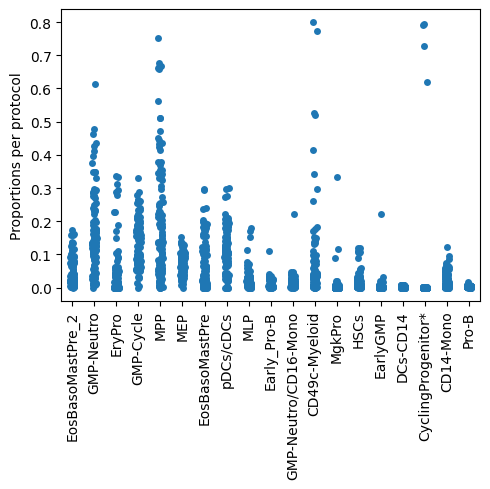

In [109]:
df = protocol_adata.obs.melt()

plt.figure(figsize=(5, 5))

sns.stripplot(
    data=df,
    x="variable",
    y="value",
    # showfliers=False  # cleaner look (optional)
)

plt.xticks(rotation=90)  # rotate labels
plt.xlabel("")
plt.ylabel("Proportions per protocol")
# plt.title("Proportions per protocols (103 unique protocols)", fontsize=14)

plt.tight_layout()
plt.show()